# EDA — MovieLens Latest Small

Exploratory analysis of the raw dataset before any filtering or preprocessing.  
Two figures:
- **Part 1** — Core distributions: ratings, user activity, movie activity, long-tail, temporal patterns
- **Part 2** — User & genre behaviour: rating bias, polarisation, genre popularity, half-star usage


## 1. Imports & Plot Style

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9", "#555555"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)


## 2. Load Data

In [ ]:
ratings = pd.read_csv("../data/raw/ratings.csv")
movies  = pd.read_csv("../data/raw/movies.csv")
tags = pd.read_csv("../data/raw/tags.csv")

ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings["year"]  = ratings["timestamp"].dt.year
ratings["month"] = ratings["timestamp"].dt.month

df = ratings.merge(movies, on="movieId")

print(f"Ratings : {len(ratings):,}")
print(f"Users   : {ratings.userId.nunique():,}")
print(f"Movies  : {ratings.movieId.nunique():,}")
print(f"Date range: {ratings.timestamp.min().date()} → {ratings.timestamp.max().date()}")

print(ratings.head())
print(movies.head())

Ratings : 100,836
Users   : 610
Movies  : 9,724
Date range: 1996-03-29 → 2018-09-24


## 3. Summary Statistics

In [10]:
n_users   = ratings["userId"].nunique()
n_movies  = ratings["movieId"].nunique()
n_ratings = len(ratings)
sparsity  = 1 - n_ratings / (n_users * n_movies)

ratings_per_user  = ratings.groupby("userId")["rating"].count()
ratings_per_movie = ratings.groupby("movieId")["rating"].count()

print(f"Sparsity       : {sparsity:.4%}")
print(f"Rating range   : {ratings.rating.min()} – {ratings.rating.max()}")
print(f"Mean rating    : {ratings.rating.mean():.3f}")
print(f"Median rating  : {ratings.rating.median():.1f}")
print()
print("Ratings per user")
print(f"  min={ratings_per_user.min()}  median={ratings_per_user.median():.0f}  "
      f"mean={ratings_per_user.mean():.1f}  max={ratings_per_user.max()}")
print()
print("Ratings per movie")
print(f"  min={ratings_per_movie.min()}  median={ratings_per_movie.median():.0f}  "
      f"mean={ratings_per_movie.mean():.1f}  max={ratings_per_movie.max()}")
print()

cold_users  = (ratings_per_user  < 5).sum()
cold_movies = (ratings_per_movie < 5).sum()
print(f"Users  with < 5 ratings : {cold_users}  ({cold_users/n_users:.1%})")
print(f"Movies with < 5 ratings : {cold_movies} ({cold_movies/n_movies:.1%})")
print()

all_genres   = df["genres"].str.split("|").explode()
genre_counts = all_genres.value_counts()
print("Top 10 genres:")
for g, c in genre_counts.head(10).items():
    print(f"  {g:<20} {c:,}")
print()

half_star = (ratings["rating"] % 1 != 0).mean()
print(f"Half-star ratings : {half_star:.1%}")


Sparsity       : 98.3000%
Rating range   : 0.5 – 5.0
Mean rating    : 3.502
Median rating  : 3.5

Ratings per user
  min=20  median=70  mean=165.3  max=2698

Ratings per movie
  min=1  median=3  mean=10.4  max=329

Users  with < 5 ratings : 0  (0.0%)
Movies with < 5 ratings : 6074 (62.5%)

Top 10 genres:
  Drama                41,928
  Comedy               39,053
  Action               30,635
  Thriller             26,452
  Adventure            24,161
  Romance              18,124
  Sci-Fi               17,243
  Crime                16,681
  Fantasy              11,834
  Children             9,208

Half-star ratings : 30.1%


## 4. Part 1 — Core Distributions

Six panels:
- **Rating distribution** — overall skew toward positive ratings
- **Ratings per user** — how active users are
- **Ratings per movie** — long-tail signal
- **Long-tail curve** — cumulative % of ratings vs % of movies
- **Mean rating per movie** — for movies with ≥20 ratings (enough to be reliable)
- **Rating activity over time** — temporal patterns


C:\Users\Hites\AppData\Local\Temp\ipykernel_2888\4166135195.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


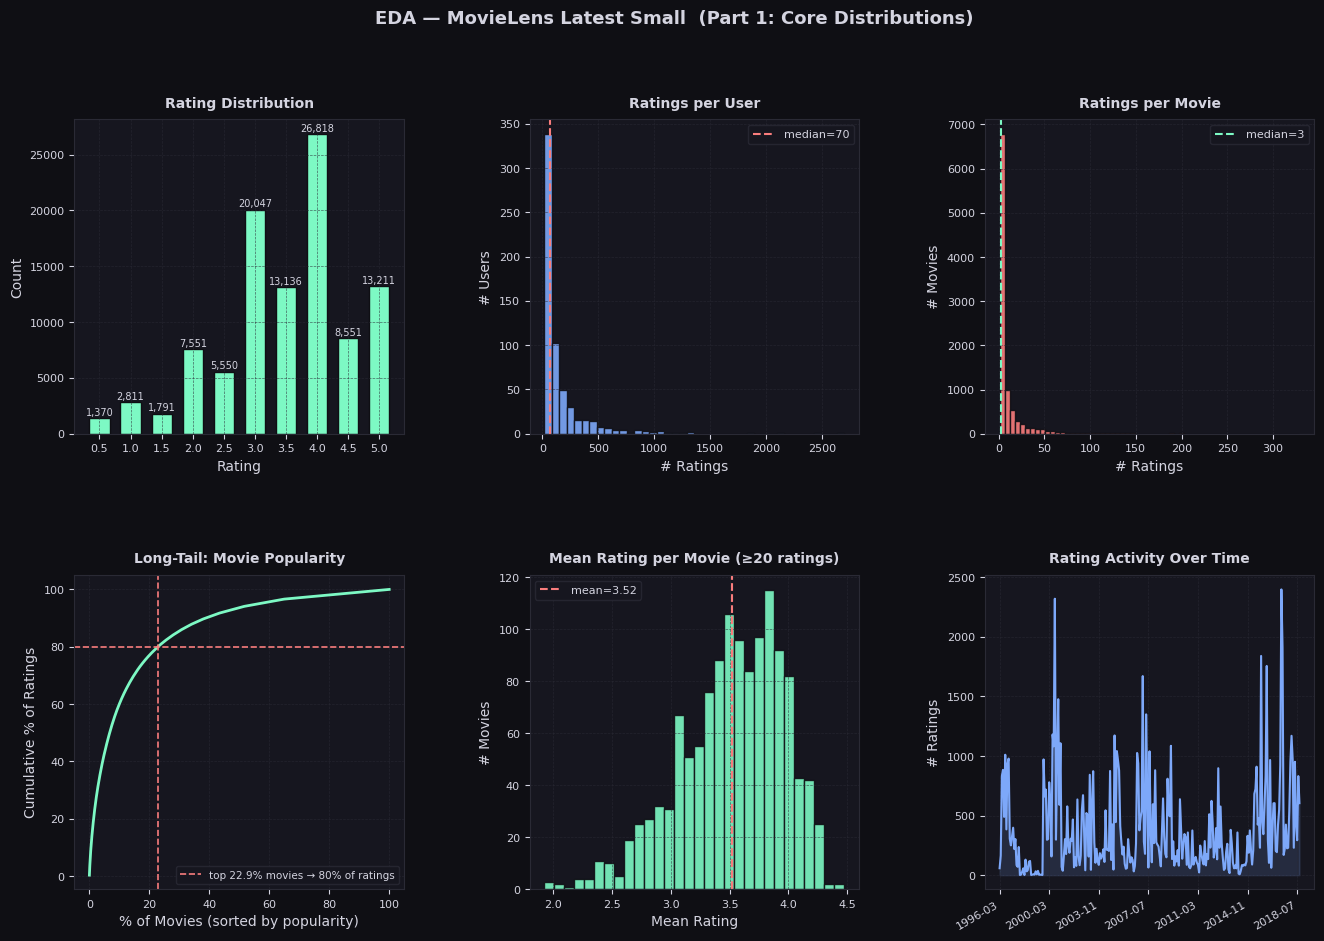

In [11]:
fig1 = plt.figure(figsize=(16, 10))
fig1.patch.set_facecolor(BG)
gs1 = gridspec.GridSpec(2, 3, figure=fig1, hspace=0.45, wspace=0.38)

# (a) Rating distribution
ax = fig1.add_subplot(gs1[0, 0])
counts = ratings["rating"].value_counts().sort_index()
bars = ax.bar(counts.index.astype(str), counts.values, color=ACCENT, edgecolor=BG, width=0.65)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 100,
            f"{b.get_height():,}", ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xlabel("Rating"); ax.set_ylabel("Count")
style_ax(ax, "Rating Distribution")

# (b) Ratings per user
ax = fig1.add_subplot(gs1[0, 1])
ax.hist(ratings_per_user, bins=40, color=ACCENT3, edgecolor=BG, alpha=0.9)
ax.axvline(ratings_per_user.median(), color=ACCENT2, lw=1.5, linestyle="--",
           label=f"median={ratings_per_user.median():.0f}")
ax.set_xlabel("# Ratings"); ax.set_ylabel("# Users")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Ratings per User")

# (c) Ratings per movie
ax = fig1.add_subplot(gs1[0, 2])
ax.hist(ratings_per_movie, bins=60, color=ACCENT2, edgecolor=BG, alpha=0.9)
ax.axvline(ratings_per_movie.median(), color=ACCENT, lw=1.5, linestyle="--",
           label=f"median={ratings_per_movie.median():.0f}")
ax.set_xlabel("# Ratings"); ax.set_ylabel("# Movies")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Ratings per Movie")

# (d) Long-tail curve
ax = fig1.add_subplot(gs1[1, 0])
sorted_counts = ratings_per_movie.sort_values(ascending=False).values
cum_ratings = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
cum_movies  = np.arange(1, len(sorted_counts)+1) / len(sorted_counts) * 100
ax.plot(cum_movies, cum_ratings, color=ACCENT, lw=2)
idx_80 = np.searchsorted(cum_ratings, 80)
ax.axvline(cum_movies[idx_80], color=ACCENT2, lw=1.2, linestyle="--")
ax.axhline(80, color=ACCENT2, lw=1.2, linestyle="--",
           label=f"top {cum_movies[idx_80]:.1f}% movies → 80% of ratings")
ax.set_xlabel("% of Movies (sorted by popularity)")
ax.set_ylabel("Cumulative % of Ratings")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=7.5)
style_ax(ax, "Long-Tail: Movie Popularity")

# (e) Mean rating per movie (≥20 ratings)
ax = fig1.add_subplot(gs1[1, 1])
mean_per_movie = df.groupby("movieId")["rating"].agg(["mean","count"])
well_rated = mean_per_movie[mean_per_movie["count"] >= 20]["mean"]
ax.hist(well_rated, bins=30, color=ACCENT, edgecolor=BG, alpha=0.9)
ax.axvline(well_rated.mean(), color=ACCENT2, lw=1.5, linestyle="--",
           label=f"mean={well_rated.mean():.2f}")
ax.set_xlabel("Mean Rating"); ax.set_ylabel("# Movies")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Mean Rating per Movie (≥20 ratings)")

# (f) Ratings over time
ax = fig1.add_subplot(gs1[1, 2])
monthly = ratings.groupby(ratings["timestamp"].dt.to_period("M")).size()
ax.plot(monthly.index.astype(str), monthly.values, color=ACCENT3, lw=1.5)
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color=ACCENT3)
tick_every = max(1, len(monthly) // 6)
ax.set_xticks(range(0, len(monthly), tick_every))
ax.set_xticklabels([str(monthly.index[i]) for i in range(0, len(monthly), tick_every)],
                   rotation=30, ha="right", fontsize=7)
ax.set_ylabel("# Ratings")
style_ax(ax, "Rating Activity Over Time")

fig1.suptitle("EDA — MovieLens Latest Small  (Part 1: Core Distributions)",
              color=TEXT_C, fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


Per-User Temporal Summary
  Span (days)           min=0  median=0  mean=234  max=6557
  Sessions per user     min=1  median=1  mean=8.7  max=707
  Ratings per session   min=2.0  median=38.6  mean=69.4  max=763.0

  Users with ≤ 3 sessions : 79.3%  ← bursty raters
  Users with ≤ 1 session  : 60.8%

Biggest gap between two sessions (per user):
  Max gap across all users : 2444 days  (6.7 years)
  Median max gap           : 74 days  (0.2 years)
  Mean max gap             : 223 days  (0.6 years)

Top 5 users by biggest gap between sessions:
 userId  max_gap_days  n_sessions
     15   2443.823287           2
    430   2066.443391          12
    132   1794.486227           7
     68   1782.824641          59
    543   1694.674653           4


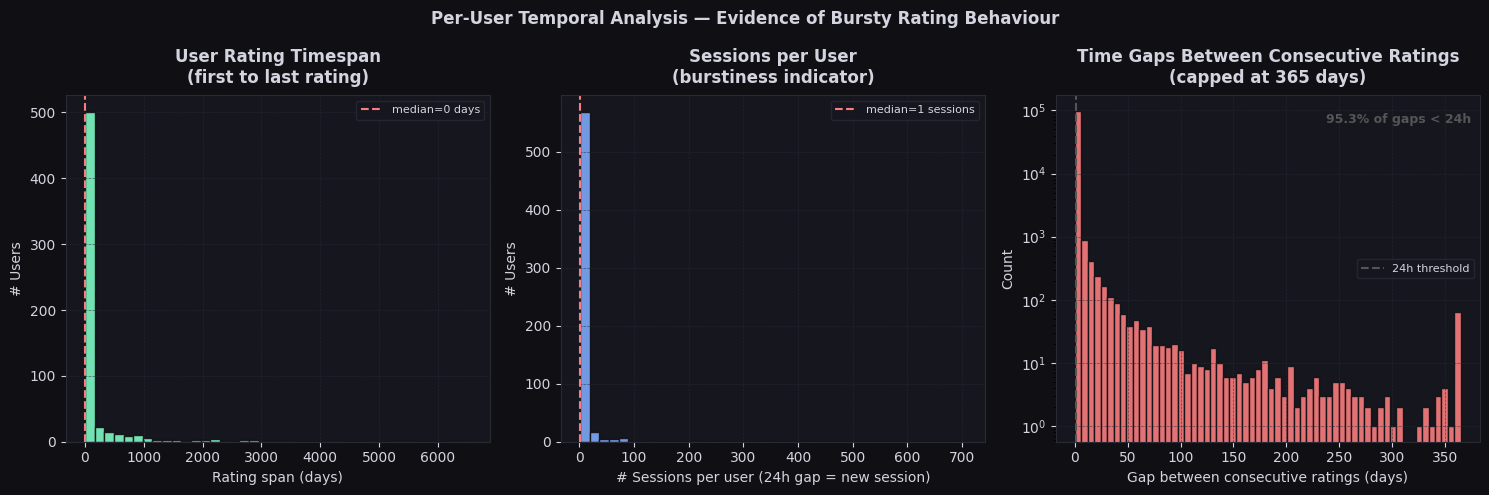


79.3% of users rated in ≤ 3 sessions — bursty, not continuous.
95.3% of consecutive gaps < 24h — ratings cluster in time.
Temporal split creates train/test from different bursty eras,


In [16]:
# ── Per-User Temporal Analysis — Proving Burstiness ───────────────────
SESSION_GAP_HOURS = 24   # ratings within 24h = same session

ratings_ts = ratings.copy()
ratings_ts["timestamp"] = pd.to_datetime(ratings_ts["timestamp"], unit="s")
ratings_ts = ratings_ts.sort_values(["userId", "timestamp"])

user_stats = []
all_gaps   = []   # time gaps between consecutive ratings (hours)

for uid, group in ratings_ts.groupby("userId"):
    group   = group.sort_values("timestamp")
    ts      = group["timestamp"]

    span_days = (ts.max() - ts.min()).days
    gaps_hours = ts.diff().dropna().dt.total_seconds() / 3600
    all_gaps.extend(gaps_hours.tolist())

    n_sessions = (gaps_hours > SESSION_GAP_HOURS).sum() + 1
    ratings_per_session = len(group) / n_sessions

    user_stats.append({
        "userId":              uid,
        "n_ratings":           len(group),
        "span_days":           span_days,
        "n_sessions":          n_sessions,
        "ratings_per_session": ratings_per_session,
        "median_gap_hours":    gaps_hours.median() if len(gaps_hours) > 0 else 0,
    })

user_df  = pd.DataFrame(user_stats)
all_gaps = pd.Series(all_gaps)

print("Per-User Temporal Summary")
print(f"  Span (days)           min={user_df.span_days.min():.0f}  "
      f"median={user_df.span_days.median():.0f}  "
      f"mean={user_df.span_days.mean():.0f}  "
      f"max={user_df.span_days.max():.0f}")
print(f"  Sessions per user     min={user_df.n_sessions.min():.0f}  "
      f"median={user_df.n_sessions.median():.0f}  "
      f"mean={user_df.n_sessions.mean():.1f}  "
      f"max={user_df.n_sessions.max():.0f}")
print(f"  Ratings per session   min={user_df.ratings_per_session.min():.1f}  "
      f"median={user_df.ratings_per_session.median():.1f}  "
      f"mean={user_df.ratings_per_session.mean():.1f}  "
      f"max={user_df.ratings_per_session.max():.1f}")
print()

bursty = (user_df.n_sessions <= 3).mean()
print(f"  Users with ≤ 3 sessions : {bursty:.1%}  ← bursty raters")
print(f"  Users with ≤ 1 session  : {(user_df.n_sessions == 1).mean():.1%}")

# ── Biggest gap between sessions per user ─────────────────────────────
session_gaps = []

for uid, group in ratings_ts.groupby("userId"):
    group      = group.sort_values("timestamp")
    ts         = group["timestamp"]
    gaps_hours = ts.diff().dropna().dt.total_seconds() / 3600
    
    # only gaps that represent session boundaries (> 24h)
    session_boundary_gaps = gaps_hours[gaps_hours > SESSION_GAP_HOURS]
    
    if len(session_boundary_gaps) > 0:
        session_gaps.append({
            "userId":        uid,
            "max_gap_days":  session_boundary_gaps.max() / 24,
            "n_sessions":    len(session_boundary_gaps) + 1,
        })

session_gaps_df = pd.DataFrame(session_gaps).sort_values("max_gap_days", ascending=False)

print("\nBiggest gap between two sessions (per user):")
print(f"  Max gap across all users : {session_gaps_df.max_gap_days.max():.0f} days  "
      f"({session_gaps_df.max_gap_days.max()/365:.1f} years)")
print(f"  Median max gap           : {session_gaps_df.max_gap_days.median():.0f} days  "
      f"({session_gaps_df.max_gap_days.median()/365:.1f} years)")
print(f"  Mean max gap             : {session_gaps_df.max_gap_days.mean():.0f} days  "
      f"({session_gaps_df.max_gap_days.mean()/365:.1f} years)")
print()
print("Top 5 users by biggest gap between sessions:")
print(session_gaps_df.head(5).to_string(index=False))

# ── Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BG)

# (a) Timespan distribution
ax = axes[0]
ax.set_facecolor(PANEL)
ax.hist(user_df.span_days, bins=40, color=ACCENT, edgecolor=BG, alpha=0.9)
ax.axvline(user_df.span_days.median(), color=ACCENT2, lw=1.5, linestyle="--",
           label=f"median={user_df.span_days.median():.0f} days")
ax.set_xlabel("Rating span (days)", color=TEXT_C)
ax.set_ylabel("# Users", color=TEXT_C)
ax.set_title("User Rating Timespan\n(first to last rating)", color=TEXT_C,
             fontweight="bold", pad=9)
ax.tick_params(colors=TEXT_C)
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
for sp in ax.spines.values(): sp.set_edgecolor(GRID_C)
ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

# (b) Sessions per user
ax = axes[1]
ax.set_facecolor(PANEL)
ax.hist(user_df.n_sessions, bins=40, color=ACCENT3, edgecolor=BG, alpha=0.9)
ax.axvline(user_df.n_sessions.median(), color=ACCENT2, lw=1.5, linestyle="--",
           label=f"median={user_df.n_sessions.median():.0f} sessions")
ax.set_xlabel("# Sessions per user (24h gap = new session)", color=TEXT_C)
ax.set_ylabel("# Users", color=TEXT_C)
ax.set_title("Sessions per User\n(burstiness indicator)", color=TEXT_C,
             fontweight="bold", pad=9)
ax.tick_params(colors=TEXT_C)
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
for sp in ax.spines.values(): sp.set_edgecolor(GRID_C)
ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

# (c) Time gaps between consecutive ratings
ax = axes[2]
ax.set_facecolor(PANEL)
gaps_capped = all_gaps.clip(upper=365*24)
ax.hist(gaps_capped / 24, bins=60, color=ACCENT2, edgecolor=BG, alpha=0.9)
ax.axvline(1, color=ACCENT4, lw=1.5, linestyle="--", label="24h threshold")
ax.set_xlabel("Gap between consecutive ratings (days)", color=TEXT_C)
ax.set_ylabel("Count", color=TEXT_C)
ax.set_title("Time Gaps Between Consecutive Ratings\n(capped at 365 days)",
             color=TEXT_C, fontweight="bold", pad=9)
ax.set_yscale("log")
ax.tick_params(colors=TEXT_C)
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
for sp in ax.spines.values(): sp.set_edgecolor(GRID_C)
ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

pct_same_session = (all_gaps < SESSION_GAP_HOURS).mean()
ax.text(0.98, 0.95, f"{pct_same_session:.1%} of gaps < 24h",
        transform=ax.transAxes, ha="right", va="top",
        color=ACCENT4, fontsize=9, fontweight="bold")

fig.suptitle("Per-User Temporal Analysis — Evidence of Bursty Rating Behaviour",
             color=TEXT_C, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n{bursty:.1%} of users rated in ≤ 3 sessions — bursty, not continuous.")
print(f"{pct_same_session:.1%} of consecutive gaps < 24h — ratings cluster in time.")
print("Temporal split creates train/test from different bursty eras,")
